# Middle-Tier ResNet50 implementation

This notebook uses the project dataset from `data/Dataset` for the binary `Fake` vs `Real` classification task. This version uses a pretrained ResNet50 backbone, light data augmentation, and a short fine-tuning stage while keeping the same train/validation/test workflow as the other mid-tier notebooks.


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd


In [2]:
# Load image data from the project data folder using the dataset's existing Train/Validation/Test split
IMAGE_SIZE = (128, 128)
SEED = 7
MAX_TRAIN_PER_CLASS = 6000
MAX_VAL_PER_CLASS = 1500
MAX_TEST_PER_CLASS = 1500
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'Dataset').exists():
            return candidate
    raise FileNotFoundError('Could not find data/Dataset from the current notebook location.')


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / 'data' / 'Dataset'
CLASS_NAMES = sorted([path.name for path in (DATA_ROOT / 'Train').iterdir() if path.is_dir()])
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}


def load_split(split_name, max_per_class=None):
    split_dir = DATA_ROOT / split_name
    rng = np.random.default_rng(SEED)
    images = []
    labels = []

    for class_name in CLASS_NAMES:
        class_dir = split_dir / class_name
        image_paths = sorted([
            path for path in class_dir.iterdir()
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        ])

        if max_per_class is not None and len(image_paths) > max_per_class:
            selected_indices = np.sort(rng.choice(len(image_paths), size=max_per_class, replace=False))
            image_paths = [image_paths[index] for index in selected_indices]

        for image_path in image_paths:
            image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
            image = keras.utils.img_to_array(image)
            images.append(image)
            labels.append(CLASS_TO_INDEX[class_name])

    x = np.array(images, dtype='float32') / 255.0
    y = np.array(labels, dtype='int32')
    return x, y


x_train, y_train = load_split('Train', MAX_TRAIN_PER_CLASS)
x_val, y_val = load_split('Validation', MAX_VAL_PER_CLASS)
x_test, y_test = load_split('Test', MAX_TEST_PER_CLASS)

print('Project root:', PROJECT_ROOT)
print('Class names:', CLASS_NAMES)
print('x_train shape:', x_train.shape)
print('x_val shape:', x_val.shape)
print('x_test shape:', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_val shape:', y_val.shape)
print('y_test shape:', y_test.shape)


Project root: /Users/nathanjohnson/playground/COMP-487-Project-1
Class names: ['Fake', 'Real']
x_train shape: (12000, 128, 128, 3)
x_val shape: (3000, 128, 128, 3)
x_test shape: (3000, 128, 128, 3)
y_train shape: (12000,)
y_val shape: (3000,)
y_test shape: (3000,)


## Implement ResNet50 for Fake vs Real classification


In [3]:
def build_resnet50_classifier(dropout_rate=0.4):
    data_augmentation = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
    ], name='augmentation')

    base_model = keras.applications.ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = data_augmentation(inputs)

    # Map normalized inputs back to the range expected by the pretrained ResNet50 preprocessing pipeline.
    x = layers.Rescaling(255.0)(x)
    x = keras.applications.resnet.preprocess_input(x)

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='ResNet50Classifier')
    return model, base_model


In [4]:
model, base_model = build_resnet50_classifier(dropout_rate=0.4)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "ResNet50Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ rescaling[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ rescaling[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ rescaling[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        514 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,120,962 (92.01 MB)

 Trainable params: 529,154 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [5]:
# Train
initial_epochs = 5
fine_tune_epochs = 5

history_frozen = model.fit(
    x_train, y_train,
    epochs=initial_epochs,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=2
)

base_model.trainable = True

# Fine-tune only the deeper layers so training stays stable on the capped dataset.
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    x_train, y_train,
    epochs=initial_epochs + fine_tune_epochs,
    initial_epoch=initial_epochs,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=2
)

history = {
    key: history_frozen.history[key] + history_fine.history[key]
    for key in history_frozen.history
}
history['epoch'] = list(range(initial_epochs + fine_tune_epochs))


Epoch 1/5
375/375 - 117s - 313ms/step - accuracy: 0.6776 - loss: 0.8001 - val_accuracy: 0.6870 - val_loss: 0.5947
Epoch 2/5
375/375 - 117s - 311ms/step - accuracy: 0.7261 - loss: 0.5430 - val_accuracy: 0.6820 - val_loss: 0.6320
Epoch 3/5
375/375 - 122s - 324ms/step - accuracy: 0.7363 - loss: 0.5243 - val_accuracy: 0.6483 - val_loss: 0.6798
Epoch 4/5
375/375 - 118s - 314ms/step - accuracy: 0.7384 - loss: 0.5236 - val_accuracy: 0.6863 - val_loss: 0.6068
Epoch 5/5
375/375 - 123s - 328ms/step - accuracy: 0.7409 - loss: 0.5162 - val_accuracy: 0.6820 - val_loss: 0.6251
Epoch 6/10
375/375 - 190s - 508ms/step - accuracy: 0.7448 - loss: 0.5049 - val_accuracy: 0.6860 - val_loss: 0.6650
Epoch 7/10
375/375 - 198s - 527ms/step - accuracy: 0.7811 - loss: 0.4542 - val_accuracy: 0.7043 - val_loss: 0.6841
Epoch 8/10
375/375 - 190s - 507ms/step - accuracy: 0.7998 - loss: 0.4175 - val_accuracy: 0.7117 - val_loss: 0.7083
Epoch 9/10
375/375 - 196s - 522ms/step - accuracy: 0.8277 - loss: 0.3773 - val_accura

In [6]:
# Evaluate training and testing accuracy
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f'Training accuracy:   {train_acc:.4f}')
print(f'Validation accuracy: {val_acc:.4f}')
print(f'Testing accuracy:    {test_acc:.4f}')


Training accuracy:   0.7882
Validation accuracy: 0.7190
Testing accuracy:    0.6673


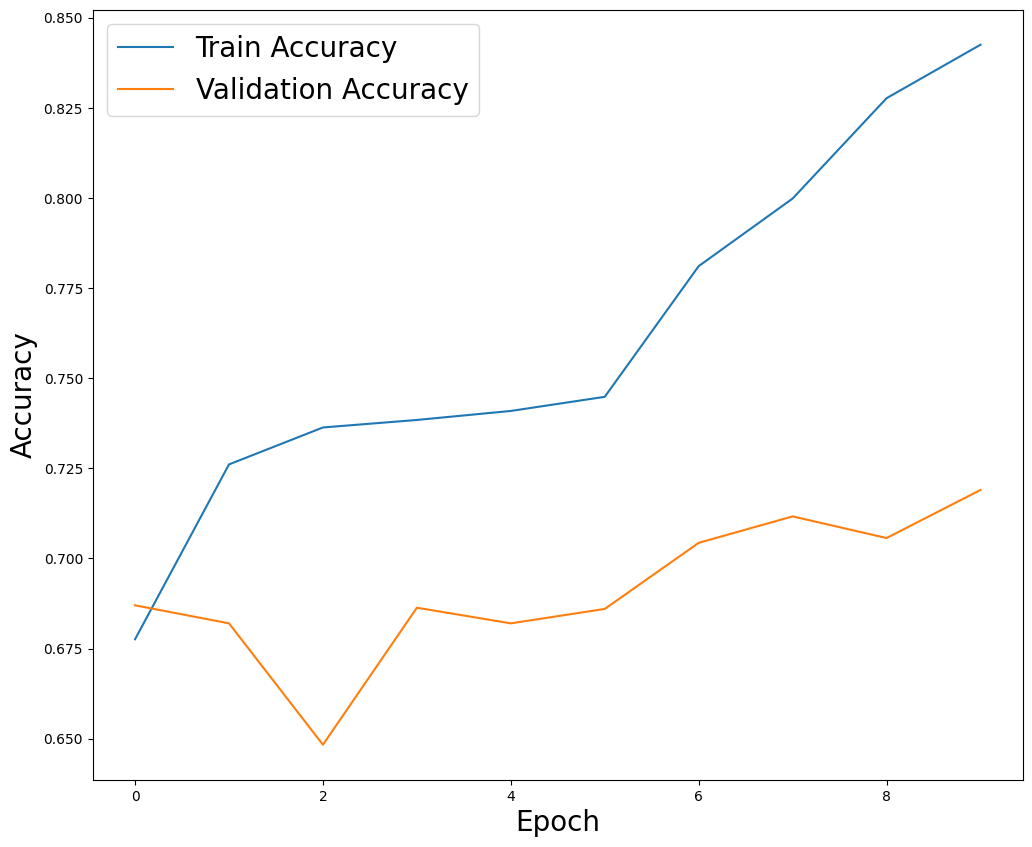

In [7]:
# Visualize training history
def plot_history(hist):
    plt.figure(figsize=(12, 10))
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel('Accuracy', fontsize=20)
    plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='Validation Accuracy')
    plt.legend(loc='upper left', prop={'size': 20})
    plt.show()


hist = pd.DataFrame(history)
plot_history(hist)


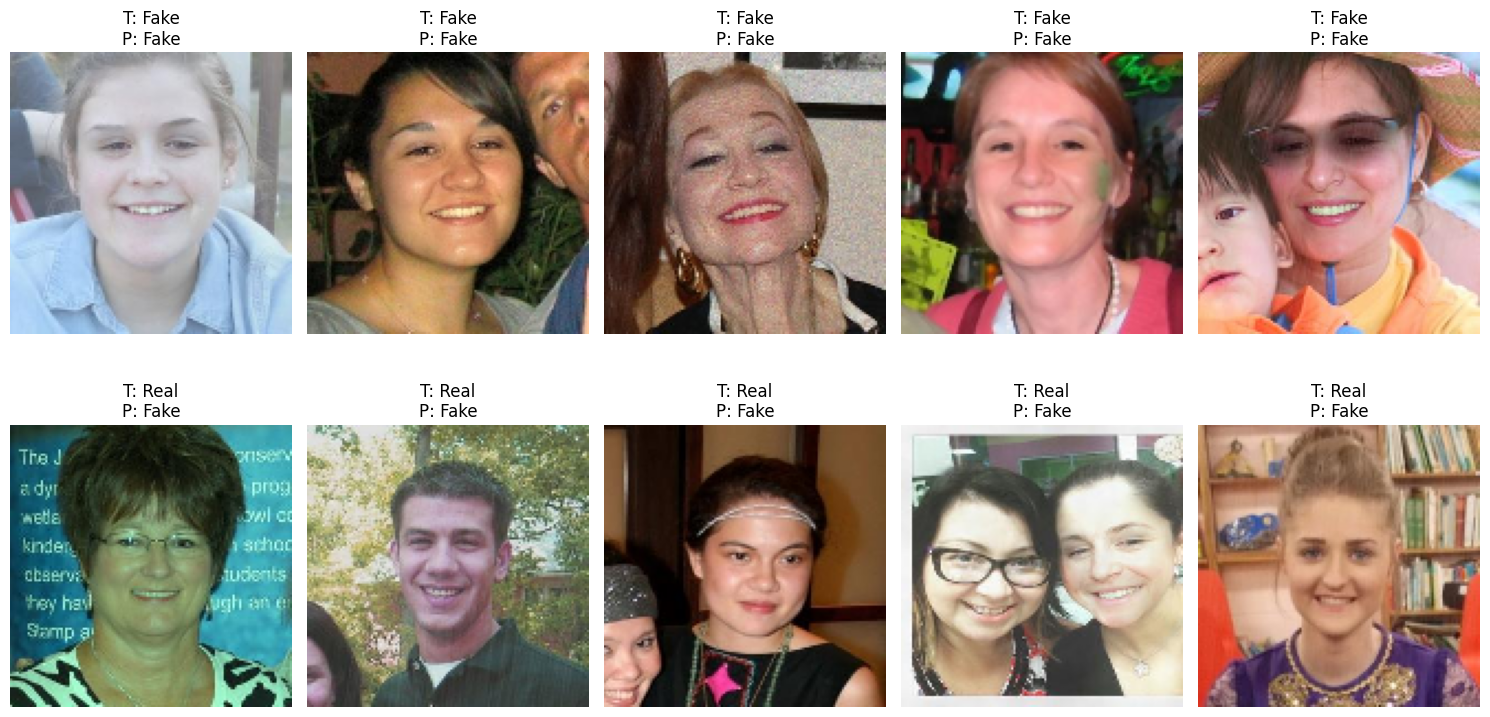

In [8]:
# Predict 5 real and 5 fake images from the test set
real_idx = np.where(y_test == CLASS_TO_INDEX['Real'])[0][:5]
fake_idx = np.where(y_test == CLASS_TO_INDEX['Fake'])[0][:5]
selected_idx = np.concatenate([fake_idx, real_idx])

images = x_test[selected_idx]
labels = y_test[selected_idx]

fig, ax = plt.subplots(2, 5, figsize=(15, 8))
ax = ax.flatten()

for i in range(10):
    img = images[i]
    true_label = labels[i]
    pred = model.predict(img[None, ...], verbose=0).argmax()

    ax[i].imshow(img)
    ax[i].set_title(
        f'T: {CLASS_NAMES[true_label]}\nP: {CLASS_NAMES[pred]}',
        fontsize=12
    )
    ax[i].axis('off')

plt.tight_layout()
plt.show()